In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Read the dataset
df = pd.read_csv("/Users/nikos/basketball-stats/data/processed/full_stats_master.csv")

In [11]:
# Aggregate points per match only for season 2025-26
team_df = (
    df[ (df['SEASON'] == '2023-24') ]
    .groupby(['DATE', 'MATCH', 'TEAM', 'OPPONENT'])['PTS']
    .sum()
    .reset_index()
)

# View the team totals
team_df.head(50)

,DATE,MATCH,TEAM,OPPONENT,PTS
0,01/02/2024,Αεροδρομιακος - Los Reys,Aerodromiakos,Los Reys,66
1,01/04/2024,San Antonio Sperms - Ανηθικοι Πιθηκοι,Anithikoi Pithikoi,San Antonio Sperms,48
2,01/04/2024,San Antonio Sperms - Ανηθικοι Πιθηκοι,San Antonio Sperms,Anithikoi Pithikoi,40
3,01/05/2024,Unleash the clowns - Chicken Nuggets BC,Chicken Nuggets BC,Unleash The Clowns,54
4,01/05/2024,Unleash the clowns - Chicken Nuggets BC,Unleash The Clowns,Chicken Nuggets BC,74
5,01/06/2024,Glyfathers - Ποσειδωνες,Glyfathers,Poseidones,71
6,01/06/2024,Glyfathers - Ποσειδωνες,Poseidones,Glyfathers,75
7,01/11/2023,Ανηθικοι Πιθηκοι - Clicka BC,Anithikoi Pithikoi,Clicka BC,52
8,01/11/2023,Ανηθικοι Πιθηκοι - Clicka BC,Clicka BC,Anithikoi Pithikoi,55
9,01/12/2023,Unflagged - Hoston Celtics,Hoston Celtics,Unflagged,45


In [12]:
team_renaming ={
    "Chicken Nuggets BC": "CNB",
    "Clicka BC": "CBC",
    "El Maestro": "ELM",
    "Evriali Warriors": "EVW",
    "Glyfathers": "GLY",
    "Hoston Celtics": "HOC",
    "Proteas Dads": "PRD",
    "South Rebels": "SRE",
    "Unleash The Clowns": "UTC",
    "Vouliagmeni Heat": "VHE",
    "Aerodromiakos": "AER",
    "Anithikoi Pithikoi": "ANP"
}

team_df['TEAM'] = team_df['TEAM'].map(team_renaming)
team_df['OPPONENT'] = team_df['OPPONENT'].map(team_renaming)

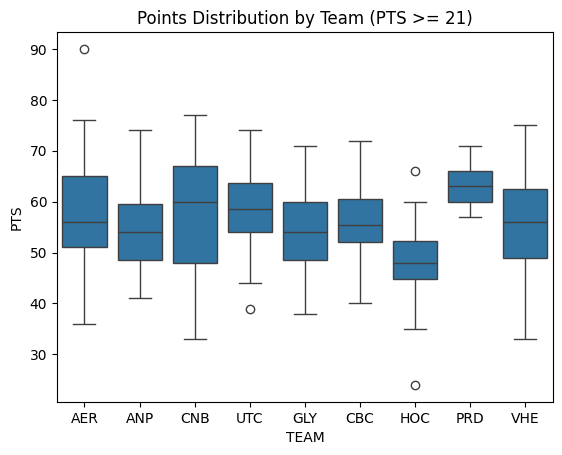

In [13]:
import seaborn as sns
filtered_team_df = team_df[team_df['PTS'] >= 21]

sns.boxplot(data=filtered_team_df, x='TEAM', y='PTS')
plt.title('Points Distribution by Team (PTS >= 21)')
plt.show()


In [14]:
team_df = (
    df[
        (df['SEASON'] == '2023-24') &
        # (df['DATE'] == '2025-05-09')
        (df['TEAM'] == 'Aerodromiakos')
    ]
    .groupby(['DATE', 'MATCH', 'OPPONENT'])['PTS']
    .sum()
    .reset_index()
    .assign(DATE=lambda x: pd.to_datetime(x['DATE'], dayfirst=True))
    .sort_values(by='DATE', ascending=False)
    .reset_index(drop=True)
)

team_df.head(50)


,DATE,MATCH,OPPONENT,PTS
0,2024-07-09,Αεροδρομιακος - Unleash the clowns,Unleash The Clowns,65
1,2024-07-02,Αεροδρομιακος - Beertuosi,Beertuosi,56
2,2024-06-27,Αεροδρομιακος - Ιασις,Iasis,53
3,2024-06-20,Αεροδρομιακος - Washington Lizards,Washington Lizards,66
4,2024-06-06,Αεροδρομιακος - Slow Motion,Slow Motion,90
5,2024-04-15,Αεροδρομιακος - Clicka BC,Clicka BC,48
6,2024-04-04,Αεροδρομιακος - Glyfathers,Glyfathers,56
7,2024-03-19,Αεροδρομιακος - Glyfathers,Glyfathers,36
8,2024-02-20,Αεροδρομιακος - Chicken Nuggets BC,Chicken Nuggets BC,76
9,2024-02-06,Αεροδρομιακος - Unleash the clowns,Unleash The Clowns,57
